<a href="https://colab.research.google.com/github/LuGorr/NLP-Assignments/blob/main/A1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group members

|  Name   |  Surname   |     Email                            |    Student ID                                             |
| :-----: | :--------: | :----------------------------------: | :-----------------------------------------------------: |
| Ludovico  | Gorrieri   | `ludovico.gorrieri@studio.unibo.it`   |  0001199160 |
| Alessandro  | Capialbi | `alessandro.capialbi@studio.unibo.it`  | 0001191564 |
| Faezeh  | Sarlakifar | `faezeh.sarlakifar@studio.unibo.it`  | 0001164608 |

## Project setup.

### Clone the repository and install the required dependencies.

In [ ]:
# @title
!git clone https://github.com/nlp-unibo/nlp-course-material.git
%cd "nlp-course-material/2025-2026/Assignment 1"
!pip install -qq gensim
print("\ngensim installed!")
!pip install -qq plotly
print("plotly installed!")
!pip install -qq nltk
print("nltk installed!")
!pip install -qq transformers
print("transformers installed!")
!pip install -qq datasets
print("datasets installed!")
!pip install -qq accelerate -U
print("accelerate installed!")
!pip install -qq evaluate
print("evaluate installed!")
!pip install -qq bitsandbytes
print("bitsandbytes installed!")
!pip install -qq wandb
print("wandb installed!")
!pip install -qq optuna
print("optuna installed!")

fatal: destination path 'nlp-course-material' already exists and is not an empty directory.
/tf/notebooks/Uni/magistrale/NLP/NLP-Assignments/A1/nlp-course-material/2025-2026/Assignment 1

gensim installed!
plotly installed!
nltk installed!
transformers installed!
datasets installed!
accelerate installed!
evaluate installed!
bitsandbytes installed!
wandb installed!
optuna installed!


### Import the reqired libraries.

In [ ]:
# System and Utils.
import os
import sys
import re
import json
import gc
import random
import ctypes
import psutil
import statistics
from random import shuffle
from collections import Counter
from itertools import product
import IPython

# Pandas and Numpy.
import numpy as np
import pandas as pd

# NLTK and Gensim.
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import (word_tokenize,
                            sent_tokenize,
                            WhitespaceTokenizer)
import gensim
import gensim.downloader as gloader
from gensim.models import KeyedVectors

# Visualization.
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Scikit-Learn, WAndB and Optuna.
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import wandb
import optuna
from optuna.trial import TrialState

# TensorFlow and Keras.
import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, Callback
from tqdm.keras import TqdmCallback
os.environ["KERAS_BACKEND"] = "tensorflow"
tf.config.run_functions_eagerly(True)

# PyTorch and HuggingFace.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup,
                          Trainer,
                          TrainingArguments,
                          EarlyStoppingCallback,
                          DataCollatorWithPadding,
                          set_seed)
import evaluate

# Define the device: use CUDA (GPU) if available, anderswise default to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-03 11:06:01.493501: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Task 1 & 2

### NTLK and function definitions.

In [ ]:
# Prepare NLTK Resources.
resources = [
    ('corpora/omw-1.4', 'omw-1.4'),
    ('corpora/wordnet', 'wordnet'),
    ('taggers/averaged_perceptron_tagger', 'averaged_perceptron_tagger'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('tokenizers/punkt', 'punkt')
]

for resource_path, download_name in resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

# Initialize the tokenizer and lemmatizer.
tokenizer = WhitespaceTokenizer()
lemmatizer = WordNetLemmatizer()

def get_wordnet_key(pos_tag):
    """
    Maps Penn Treebank POS tags to WordNet's format
    (Required by WordNetLemmatizer).
    """
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

def lem_text(row):
    """
    Tokenizes and lemmatizes a row's tweet.
    """
    tokens = tokenizer.tokenize(row.tweet) # Tokenize.
    tagged = pos_tag(tokens) # Tag the tokens.

    # Convert the tagged tokens to WordNet and lemmatize them.
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

def cleaner(row):
    """
    Cleans a row's tweet.
    """
    text = row.tweet
    text = text.lower() # Transform to lowercase.
    text = re.sub(r'https?:\/\/.\S+', '', text) # Remove URLs.
    text = re.sub(r'[@#].\S+', '', text) # Remove hashtags and mentions.

    text = re.sub( # Remove unwanted symbols.
        "["
            u"\U0001F600-\U0001F64F"  # Emoticons.
            u"\U0001F300-\U0001F5FF"  # Symbols & pictographs.
            u"\U0001F680-\U0001F6FF"  # Transport & map symbols.
            u"\U0001F1E0-\U0001F1FF"  # Flags.
                                    "]+", '', text
    )
    # Only keep numbers and latin alphabet letters.
    text = re.sub(r'[^a-z^0-9^\s]*', '', text)

    text = ' '.join(text.split())
    return text

def plot_dists(train, test, extra_title=""):
    """
    Plots train and test set distributions.
    - Class distribution (in percentage points over the set).
    - Tweet length distribution.
    - Per class tweet length distribution.
    """
    # Class distribution histogram.
    pio.renderers.default = "colab"
    label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}
    category_order = ["NOT SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]
    train_plot = train.copy()
    test_plot = test.copy()
    train_plot["dataset"] = "Training Set"
    test_plot["dataset"] = "Test Set"
    df_all = pd.concat([train_plot, test_plot])
    df_all["label_name"] = df_all["label"].map(label_map)
    df_counts = df_all.groupby(['dataset', 'label_name']).size().reset_index(name='counts')
    df_counts['percent'] = df_counts.groupby('dataset')['counts'].transform(lambda x: (x / x.sum()) * 100)
    fig = px.bar(
        df_counts,
        x="label_name",
        y="percent",
        color="label_name",
        facet_col_spacing=0.05,
        facet_col="dataset",
        category_orders={"label_name": category_order, "dataset": ["Training Set", "Test Set"]},
        color_discrete_sequence=px.colors.sequential.Plasma,
        text=df_counts['percent'].apply(lambda x: f'{x:.1f}%'), # Etichette precise
        labels={"label_name": "Class", "percent": "Percentage (%)"}
    )
    fig.update_layout(
        width=1000, height=500,
        showlegend=False,
        bargap=0.2,
        title_text="Class Distribution: Percentage of each Set " + extra_title,
        title_x=0.5
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    fig.update_traces(textposition='outside') # Mette i numeri sopra le barre
    fig.update_yaxes(title_text="Percentage (%)", ticksuffix="%")
    fig.show()

    # Tweet length distribution histogram + kernel density estimator.
    train_plot["text_length"] = train_plot["text"].apply(lambda x: len(x.split()))
    plt.figure(figsize=(10,5))
    sns.histplot(train_plot["text_length"], bins=30, kde=True, color="purple")
    plt.title("Distribution of Tweet Lengths (Training Set)")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

    # Per class tweet length distribution boxplot.
    plt.figure(figsize=(8,5))
    sns.boxplot(x="label", y="text_length",hue="label", legend=False, data=train_plot, palette="viridis")
    plt.title("Tweet Length by Class")
    plt.xlabel("Class")
    plt.ylabel("Tweet Length (words)")
    plt.xticks([0,1,2,3], ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'])
    plt.show()

# Aggregates the labels (labels_task2).


def aggregator(row):

    mapping = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
    }

    votes = [vote for vote in row.labels_task2 if vote != "UNKNOWN"]
    counts = Counter(votes)

    if not counts:
        return None

    top_two = counts.most_common(2)

    # 1. If everyone agreed or there's only one type of label
    if len(top_two) == 1:
        return mapping[top_two[0][0]]

    # 2. Check for a clear majority (Top vote > Second place vote)
    if top_two[0][1] > top_two[1][1]:
        return mapping[top_two[0][0]]

    # 3. If there is a tie (e.g., 3 vs 3), return None to filter out later
    return None

def random_upsampler(ds):
    label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}

    # Count the labels.
    label_counts = [ds.label[ds.label == i].count() for i in label_map.keys()]

    majority = np.argmax(label_counts) # Get the majority class.

    # Perform random upsampling until all the classes have an equal amount of entries.
    for i in label_map:
        if i != majority:
            for _ in range(label_counts[majority] - label_counts[i]):
                ds = pd.concat([pd.DataFrame(ds[ds.label == i].sample(1), \
                                columns=ds.columns), ds], ignore_index=True)

    ds = ds.reset_index(drop=True)
    print("AUGMENTATION DONE!")
    return ds



### Clean, split and lemmatize the dataset.

train_LSTM
test_LSTM
val_LSTM
train_ROBERTA
test_ROBERTA
val_ROBERTA
                                                       text  label
id_EXIST                                                          
200001    ffs how about lay the blame on the bastard who...      0
200002    write a uni essay in my local pub with a coffe...      3
200003    it be 2021 not 1921 i dont appreciate that on ...      3
200004    this be unacceptable use her title a you do fo...      0
200005    make yourself a hard target basically boil dow...      0
...                                                     ...    ...
203254    maam if i say that you look like a whorewould ...      1
203256    idk why yall bitch think have half your as han...      1
203257    this have be a part of an experiment with what...      2
203258    take me already not yet you gotta be readyim d...      1
203259                      why do you look like a whore lh      1

[2873 rows x 2 columns]


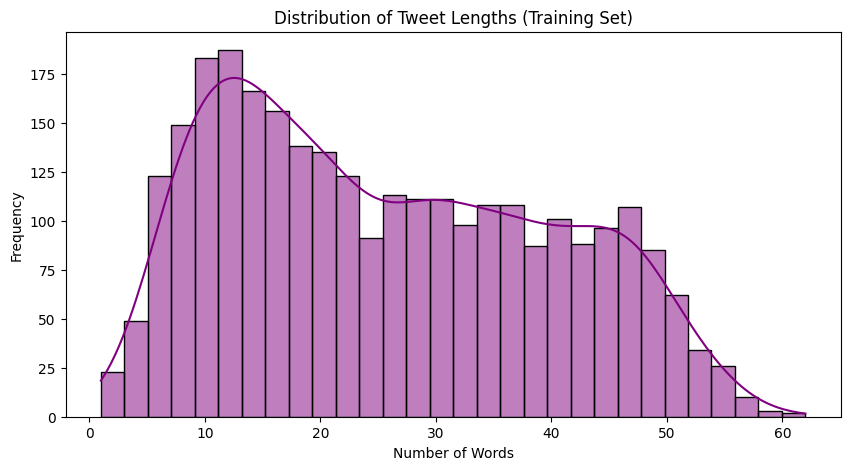

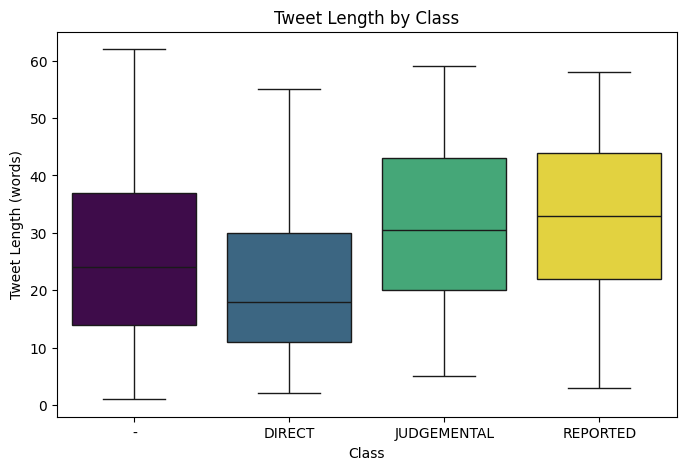

In [ ]:
# Load the JSON files.
with open("data/training.json", "r") as tr, \
     open("data/validation.json", "r") as te, \
     open("data/test.json", "r") as va:
    train_json = json.load(tr)
    val_json = json.load(te)
    test_json = json.load(va)

# Create the dataframes (setting the index to id_EXIST).
dts = {
    "train_LSTM": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test_LSTM": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val_LSTM": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST"),
    "train_ROBERTA": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test_ROBERTA": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val_ROBERTA": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST")
}

# Unnecessary columns
drop_cols = ["number_annotators", "annotators", "gender_annotators",
    "age_annotators", "labels_task1", "labels_task3", "split", "lang"]

is_roberta = re.compile(r"_ROBERTA")

# Clean and lemmatize the data
for name, df in dts.items():
    print(name)
    df = df[df.lang == "en"].copy() # Drop spanish.

    df = df.drop(columns=drop_cols) # Drop unnecessary cols.

    df["labels"] = df.apply(aggregator, axis=1) # Aggregate the labels (maj. voting).
    # Remove rows where aggregator returned None (no clear majority)
    df = df.dropna(subset=['labels'])

    # Convert to integer
    df['labels'] = df['labels'].astype(int)

    df = df.drop(columns="labels_task2") # Drop the old label column.
    if(is_roberta.search(name) is None):
        for func in [cleaner, lem_text]:
            df["tweet"] = df.apply(func, axis=1) # Clean the tweets.

    # Rename the columns
    df.rename(columns={"tweet": "text", "labels": "label"}, inplace=True)

    dts[name] = df

# Get the clean train, test and validation datasets
train_LSTM, test_LSTM, val_LSTM, \
train_ROBERTA, test_ROBERTA, val_ROBERTA = dts.values()

print(train_LSTM)

# Plot the dataset distributions.
plot_dists(train_LSTM, test_LSTM, "(LSTM Before Augmentation)")

### Dataset augmentation by random upsampling.

AUGMENTATION DONE!


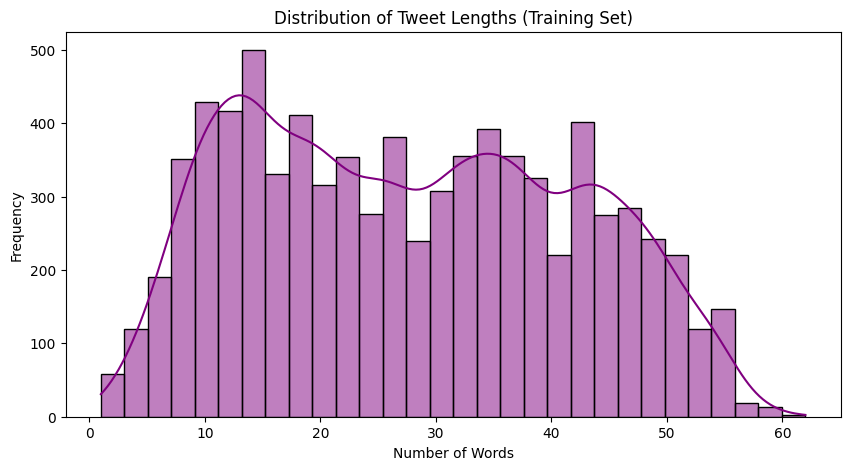

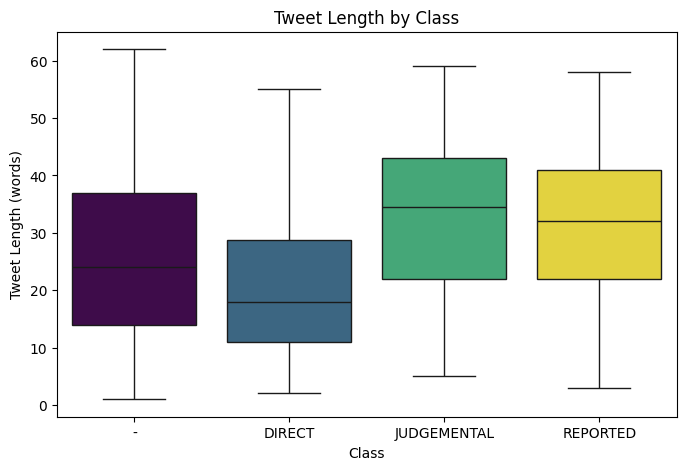

In [ ]:
train_LSTM = random_upsampler(train_LSTM)
plot_dists(train_LSTM, test_LSTM)

## Task 3: Text Encoding

### Build the vocabulary

In [ ]:
vectorizer = layers.TextVectorization()
vectorizer.adapt(train_LSTM["text"])

I0000 00:00:1767438374.070750   14669 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15480 MB memory:  -> device: 0, name: AMD Radeon RX 7800 XT, pci bus id: 0000:2d:00.0


In [ ]:
X_train_vec = vectorizer(train_LSTM["text"]).numpy()
X_val_vec = vectorizer(val_LSTM["text"]).numpy()
X_test = vectorizer(test_LSTM["text"]).numpy()
y_train = train_LSTM["label"].values
y_val = val_LSTM["label"].values
y_test = test_LSTM["label"].values

The vectorizer has its vocabulary frozen after adapt().

When we apply it to the val or test set,

any word not seen during training will automatically be replaced with the OOV token (default **UNK**, index 1).

We do not need to manually preprocess or map OOV tokens, TensorFlow will handle it internally.

### Use GloVe Embedding vectors

#### Convert GloVe format to Word2Vec format

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    glove_dst_50 = "/content/drive/MyDrive/glove.twitter.27B.50d.txt"
    glove_dst_100 = "/content/drive/MyDrive/glove.twitter.27B.100d.txt"
else:
    glove_dst_50 = "glove.twitter.27B.50d.txt"
    glove_dst_100 = "glove.twitter.27B.100d.txt"
glove_src_50 = "glove.twitter.27B.50d.txt"
glove_src_100 = "glove.twitter.27B.100d.txt"

if os.path.exists(glove_dst_50) and os.path.exists(glove_dst_100):
    print("GloVe files already exists in Drive.")
else:
    print("Downloading GloVe files...")
    !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
    !unzip -q glove.twitter.27B.zip
    print("Copying GloVe file...")
    !cp "$glove_src_50" "$glove_dst_50"
    !cp "$glove_src_100" "$glove_dst_100"
    print("Files copied successfully!")

glove_file_50 = glove_dst_50
glove_file_100 = glove_dst_100

GloVe files already exists in Drive.


In [ ]:
# Load GloVe into Gensim
twitter_glove_50 = KeyedVectors.load_word2vec_format(glove_file_50, binary=False, no_header=True)
twitter_glove_100 = KeyedVectors.load_word2vec_format(glove_file_100, binary=False, no_header=True)

print(f"Loaded Twitter GloVe with {len(twitter_glove_50.key_to_index):,} and {len(twitter_glove_100.key_to_index):,} tokens")

Loaded Twitter GloVe with 1,193,514 and 1,193,514 tokens


#### Build TensorFlow embedding matrix

In [ ]:
vocab = vectorizer.get_vocabulary()
embedding_dims = [twitter_glove_50.vector_size, twitter_glove_100.vector_size]
embedding_matrixes = [np.zeros((len(vocab), embedding_dims[0])), np.zeros((len(vocab), embedding_dims[1]))]

### OOV handling

#### Random embedding initialization for OOV words

Then we will learn them by training

In [ ]:
# Construct the embedding matrix using GloVe vectors or random initialization
# For each word in the vocabulary:
# - If the word exists in the pre-trained GloVe embeddings, use its vector.
# - Otherwise, initialize its vector with random values drawn from a uniform distribution
count_0 = 0
count_1 = 0
for i, word in enumerate(vocab):
    if i == 0: # Handling zero mask
        continue
    if word in twitter_glove_50:
        embedding_matrixes[0][i] = twitter_glove_50[word]
        embedding_matrixes[1][i] = twitter_glove_100[word]
        count_0 += 1
    else:
        embedding_matrixes[0][i] = np.random.uniform(low=-0.05, high=0.05, size=embedding_dims[0])
        embedding_matrixes[1][i] = np.random.uniform(low=-0.05, high=0.05, size=embedding_dims[1])
        count_1 += 1
print(count_0)
print(count_1)

7903
1902


## Task 4 & 5

In [ ]:
def get_callbacks(verbose):
    return [ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=3,
      min_lr=1e-6,
      verbose=verbose
  ), tf.keras.callbacks.EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=verbose
    ), TqdmCallback(verbose=0)]

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Converte y_true da (batch,) a (batch, num_classes)
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        super().update_state(y_true, y_pred, sample_weight)

def build_model(units=64, dense=64, trainable_embeddings=False, stacked=False, lr=1e-3, dropout=0.0, l2=0.0):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dims[stacked],
            weights=[embedding_matrixes[stacked]],
            mask_zero=False,
            trainable=trainable_embeddings,
            name='encoder-embedding'
        ),
        layers.Bidirectional(
            layers.LSTM(units,
                        return_sequences=stacked,
                        kernel_regularizer=regularizers.l2(l2),
                        recurrent_activation='relu',
                        unroll=True
                       )
        ),
        #layers.LayerNormalization(),
        layers.Dropout(dropout),
        layers.Bidirectional(
            layers.LSTM(units,
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(l2),
                        recurrent_activation='relu',
                        unroll=True
                        )
                       ) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        layers.Dropout(dropout) if stacked else layers.Identity(),
        layers.Dense(
            dense,
            activation = "leaky_relu",
            kernel_regularizer=regularizers.l2(l2)
        ),
        layers.Dropout(dropout),
        layers.Dense(4, activation='softmax')
    ])
    f1_metric = SparseF1Score(average='macro', name='f1_score')
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipvalue=1.0),
        metrics=['accuracy', f1_metric],
        jit_compile=False
    )
    return model

def predict_batch(model, x):
    return model(x, training=False)

def evaluate_model(model, X_test, y_test, class_names=['NOT SEXIST', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']):
    """
    Compute macro F1, precision, recall, and display classification report
    and confusion matrix on the validation set.
    """
    y_true = []
    y_pred_probs = []

    # Iterate over the validation dataset

    # Get model predictions (probabilities) using the tf.function
    preds = predict_batch(model, X_test)
    # Get the predicted class index (the one with the highest probability)
    y_pred = np.argmax(preds, axis=1)

    # 1. Print the detailed Classification Report
    # This shows precision, recall, f1-score for each class
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print("---------------------------------")

    # 2. Compute and display the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nPlotting Confusion Matrix...")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {name}' for name in class_names],
                yticklabels=[f'True {name}' for name in class_names])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Calculate macro-averaged metrics
    # 'macro' calculates metrics for each label, and finds their unweighted mean.
    # This is crucial for imbalanced datasets.
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    return f1, prec, rec

def set_deterministic(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [ ]:
def get_process_memory():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)  # MB

def objective(trial, stacked_mode):
    hp = {
        'units': trial.suggest_categorical('units', [32, 64, 128]),
        'dense': trial.suggest_categorical('dense', [32, 64, 128]),
        'lr': trial.suggest_categorical('lr', [1e-2, 1e-3, 5e-4, 1e-4]),
        'l2': trial.suggest_categorical('l2', [1e-5, 1e-4, 1e-3, 1e-2]),
        'dropout': trial.suggest_float('dropout', 0.0, 0.8, step=0.2),
        'trainable_emb': trial.suggest_categorical('trainable_emb', [True, False])
    }

    print(f"\n[Trial {trial.number}] Stacked={stacked_mode} | Params: {hp}")

    score = 0.0
    seeds = [888, 777, 999]
    model = None
    history = None
    try:
        for seed in seeds:
            set_deterministic(seed)
            model = build_model(
                units=hp['units'],
                dense=hp['dense'],
                trainable_embeddings=hp['trainable_emb'],
                stacked=stacked_mode,
                lr=hp['lr'],
                dropout=hp['dropout'],
                l2=hp['l2']
            )
            history = model.fit(
                x=X_train_vec,
                y=y_train,
                validation_data=(X_val_vec, y_val),
                epochs=30,
                verbose=0,
                batch_size=512,
                shuffle=True,
                callbacks=get_callbacks(False)
            )
            score = max(history.history['val_f1_score'])/3 + score
        print(f" -> Result: Val_F1={score:.4f} | RAM: {get_process_memory():.1f} MB")
    except Exception as e:
        print(f" -> ERROR Trial {trial.number}: {e}")
        score = 0.0
    return score

storage_path = "sqlite:///optimization_results.db"

study_base = optuna.create_study(
    study_name="base_lstm_study_seeded",
    storage=storage_path,
    load_if_exists=True,
    direction="maximize"
)
base_trials = 60 - len([t for t in study_base.trials if t.state == TrialState.COMPLETE])

if base_trials > 0:
    print("\n" + "="*40)
    print(" STARTING BASE LSTM OPTIMIZATION")
    print("="*40)
    study_base.optimize(lambda t: objective(t, False), n_trials = base_trials)
else:
    print("COMPLETED BASE LSTM STUDY FOUND")

study_stacked = optuna.create_study(
    study_name="stacked_lstm_study_seeded",
    storage=storage_path,
    load_if_exists=True,
    direction="maximize"
)
stacked_trials = 60 - len([t for t in study_stacked.trials if t.state == TrialState.COMPLETE])

if stacked_trials > 0:
    print("\n" + "="*40)
    print(" STARTING STACKED LSTM OPTIMIZATION")
    print("="*40)
    study_base.optimize(lambda t: objective(t, True), n_trials = stacked_trials)
else:
    print("COMPLETED STACKED LSTM STUDY FOUND")

for name, study in [("BASE", study_base), ("STACKED", study_stacked)]:
    if len(study.trials) > 0:
        print(f"\n--- Best {name} ---")
        print(f"Val_F1: {study.best_value:.4f}")
        print(f"Params: {study.best_params}")

[I 2026-01-03 10:30:51,139] A new study created in RDB with name: base_lstm_study_seeded



 STARTING BASE LSTM OPTIMIZATION

[Trial 0] Stacked=False | Params: {'units': 128, 'dense': 128, 'lr': 0.0005, 'l2': 0.001, 'dropout': 0.0, 'trainable_emb': False}


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 53%|██████████████████▋                | 16/30 [01:49<01:35,  6.81s/epoch, accuracy=0.25, f1_score=0, loss=nan, val_accuracy=0.7, val_f1_score=0, val_loss=nan, learning_rate=0.00025]
[I 2026-01-03 10:38:34,388] Trial 0 finished with value: 0.39694830775260925 and parameters: {'units': 128, 'dense': 128, 'lr': 0.0005, 'l2': 0.001, 'dropout': 0.0, 'trainable_emb': False}. Best is trial 0 with value: 0.39694830775260925.


 -> Result: Val_F1=0.3969 | RAM: 4576.2 MB

[Trial 1] Stacked=False | Params: {'units': 128, 'dense': 64, 'lr': 0.0001, 'l2': 0.0001, 'dropout': 0.2, 'trainable_emb': False}


 67%|████████████████▋        | 20/30 [02:18<01:09,  6.94s/epoch, accuracy=0.636, f1_score=0.633, loss=0.972, val_accuracy=0.34, val_f1_score=0.285, val_loss=1.34, learning_rate=5e-5]
[I 2026-01-03 10:42:58,816] Trial 1 finished with value: 0.2489970674117406 and parameters: {'units': 128, 'dense': 64, 'lr': 0.0001, 'l2': 0.0001, 'dropout': 0.2, 'trainable_emb': False}. Best is trial 0 with value: 0.39694830775260925.


...

 -> Result: Val_F1=0.2860 | RAM: 4771.0 MB

[Trial 3] Stacked=False | Params: {'units': 64, 'dense': 32, 'lr': 0.0005, 'l2': 0.001, 'dropout': 0.6000000000000001, 'trainable_emb': False}


 93%|██████████████████████▍ | 28/30 [03:15<00:13,  7.00s/epoch, accuracy=0.79, f1_score=0.791, loss=0.621, val_accuracy=0.5, val_f1_score=0.282, val_loss=1.35, learning_rate=0.00025]
[I 2026-01-03 10:54:52,011] Trial 3 finished with value: 0.30574659506479895 and parameters: {'units': 64, 'dense': 32, 'lr': 0.0005, 'l2': 0.001, 'dropout': 0.6000000000000001, 'trainable_emb': False}. Best is trial 0 with value: 0.39694830775260925.


 -> Result: Val_F1=0.3057 | RAM: 4769.5 MB

[Trial 4] Stacked=False | Params: {'units': 32, 'dense': 32, 'lr': 0.0001, 'l2': 0.01, 'dropout': 0.0, 'trainable_emb': False}


 23%|█████▊                   | 7/30 [00:48<02:37,  6.86s/epoch, accuracy=0.32, f1_score=0.313, loss=2.98, val_accuracy=0.353, val_f1_score=0.227, val_loss=2.94, learning_rate=0.0001][W 2026-01-03 10:56:30,516] Trial 4 failed with parameters: {'units': 32, 'dense': 32, 'lr': 0.0001, 'l2': 0.01, 'dropout': 0.0, 'trainable_emb': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_20/4264431310.py", line 64, in <lambda>
    study_base.optimize(lambda t: objective(t, False), n_trials = base_trials)
                                  ^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_20/4264431310.py", line 33, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/keras/src/utils/traceback_utils.py", line 117, in 

KeyboardInterrupt: 


Training baseline model with seed 123...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 37%|█▊   | 11/30 [01:01<01:47,  5.65s/epoch, accuracy=0.843, f1_score=0.843, loss=0.573, val_accuracy=0.607, val_f1_score=0.377, val_loss=1.28, learning_rate=0.001]


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 50%|██▌  | 15/30 [01:27<01:33,  6.23s/epoch, accuracy=0.885, f1_score=0.884, loss=0.471, val_accuracy=0.62, val_f1_score=0.339, val_loss=1.21, learning_rate=0.0005]

Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.


 50%|██▌  | 15/30 [01:27<01:27,  5.81s/epoch, accuracy=0.885, f1_score=0.884, loss=0.471, val_accuracy=0.62, val_f1_score=0.339, val_loss=1.21, learning_rate=0.0005]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.79      0.63      0.70       179
      DIRECT       0.41      0.56      0.47        62
 JUDGEMENTAL       0.07      0.11      0.09        18
    REPORTED       0.16      0.19      0.17        21

    accuracy                           0.55       280
   macro avg       0.36      0.37      0.36       280
weighted avg       0.61      0.55      0.57       280

---------------------------------

Plotting Confusion Matrix...


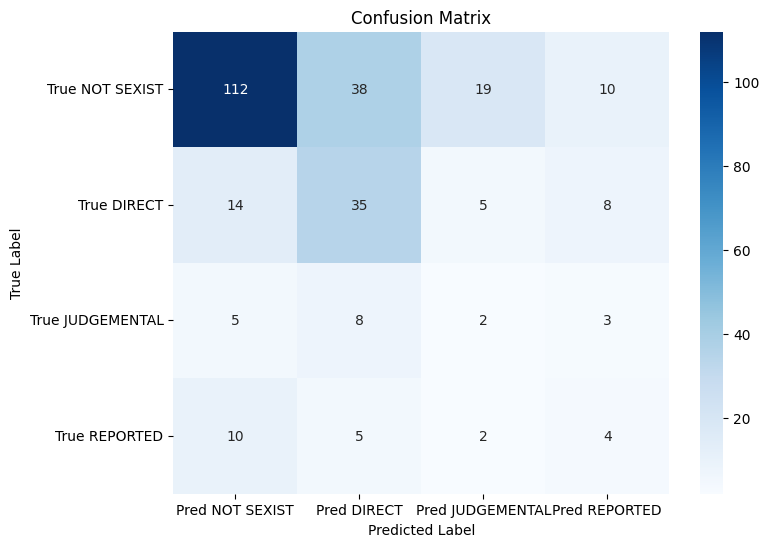


Training stacked model with seed 123...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 27%|█▊     | 8/30 [01:32<04:20, 11.84s/epoch, accuracy=0.703, f1_score=0.701, loss=0.963, val_accuracy=0.353, val_f1_score=0.285, val_loss=1.6, learning_rate=0.001]

Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


 27%|█▊     | 8/30 [01:32<04:13, 11.52s/epoch, accuracy=0.703, f1_score=0.701, loss=0.963, val_accuracy=0.353, val_f1_score=0.285, val_loss=1.6, learning_rate=0.001]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.81      0.44      0.57       179
      DIRECT       0.35      0.56      0.43        62
 JUDGEMENTAL       0.05      0.06      0.05        18
    REPORTED       0.15      0.43      0.22        21

    accuracy                           0.44       280
   macro avg       0.34      0.37      0.32       280
weighted avg       0.61      0.44      0.48       280

---------------------------------

Plotting Confusion Matrix...


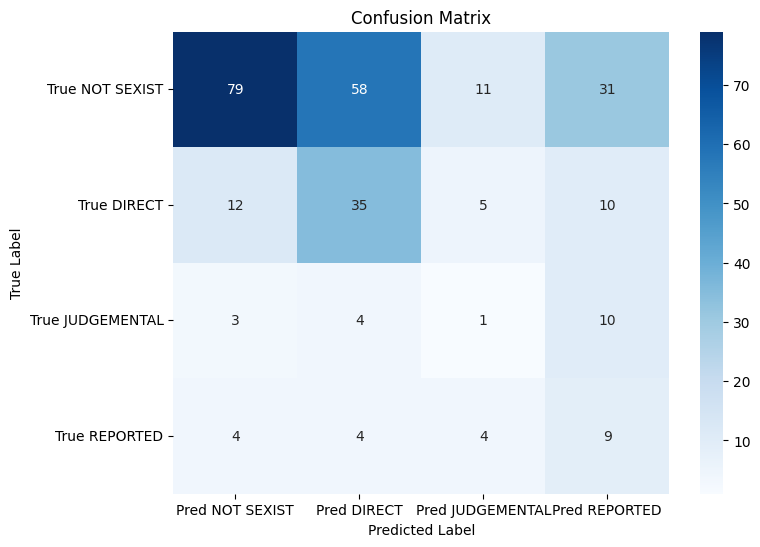


Training baseline model with seed 420...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 23%|██       | 7/30 [00:39<02:08,  5.58s/epoch, accuracy=0.78, f1_score=0.778, loss=0.73, val_accuracy=0.547, val_f1_score=0.37, val_loss=1.39, learning_rate=0.001]


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 33%|█▎  | 10/30 [00:55<01:51,  5.57s/epoch, accuracy=0.838, f1_score=0.835, loss=0.586, val_accuracy=0.527, val_f1_score=0.337, val_loss=1.52, learning_rate=0.0005]


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


...


Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


 47%|█▍ | 14/30 [01:18<01:29,  5.57s/epoch, accuracy=0.886, f1_score=0.885, loss=0.457, val_accuracy=0.567, val_f1_score=0.352, val_loss=1.58, learning_rate=0.00025]

Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.


 47%|█▍ | 14/30 [01:18<01:29,  5.58s/epoch, accuracy=0.886, f1_score=0.885, loss=0.457, val_accuracy=0.567, val_f1_score=0.352, val_loss=1.58, learning_rate=0.00025]


--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.77      0.56      0.65       179
      DIRECT       0.36      0.50      0.42        62
 JUDGEMENTAL       0.09      0.11      0.10        18
    REPORTED       0.17      0.33      0.23        21

    accuracy                           0.50       280
   macro avg       0.35      0.38      0.35       280
weighted avg       0.59      0.50      0.53       280

---------------------------------

Plotting Confusion Matrix...


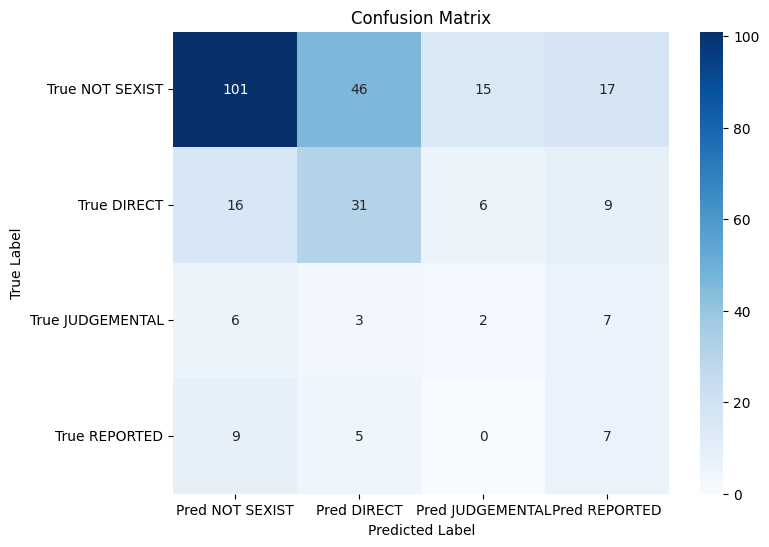


Training stacked model with seed 420...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 37%|██▏   | 11/30 [02:04<03:34, 11.28s/epoch, accuracy=0.807, f1_score=0.808, loss=0.819, val_accuracy=0.627, val_f1_score=0.38, val_loss=1.45, learning_rate=0.001]


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 47%|█▊  | 14/30 [02:37<02:56, 11.04s/epoch, accuracy=0.882, f1_score=0.882, loss=0.634, val_accuracy=0.647, val_f1_score=0.365, val_loss=1.49, learning_rate=0.0005]

Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.


 47%|█▊  | 14/30 [02:37<02:59, 11.23s/epoch, accuracy=0.882, f1_score=0.882, loss=0.634, val_accuracy=0.647, val_f1_score=0.365, val_loss=1.49, learning_rate=0.0005]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.78      0.67      0.72       179
      DIRECT       0.47      0.53      0.50        62
 JUDGEMENTAL       0.17      0.11      0.13        18
    REPORTED       0.24      0.52      0.33        21

    accuracy                           0.59       280
   macro avg       0.42      0.46      0.42       280
weighted avg       0.63      0.59      0.61       280

---------------------------------

Plotting Confusion Matrix...


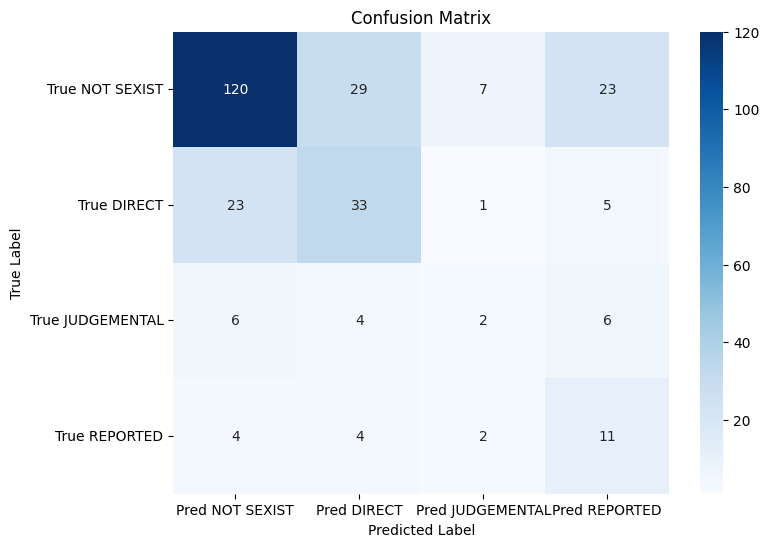


Training baseline model with seed 2026...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 27%|██▍      | 8/30 [00:50<02:22,  6.46s/epoch, accuracy=0.804, f1_score=0.803, loss=0.654, val_accuracy=0.48, val_f1_score=0.29, val_loss=1.4, learning_rate=0.001]


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 33%|█▎  | 10/30 [01:02<02:00,  6.01s/epoch, accuracy=0.821, f1_score=0.819, loss=0.619, val_accuracy=0.527, val_f1_score=0.319, val_loss=1.42, learning_rate=0.0005]

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


 33%|█▎  | 10/30 [01:02<02:04,  6.20s/epoch, accuracy=0.821, f1_score=0.819, loss=0.619, val_accuracy=0.527, val_f1_score=0.319, val_loss=1.42, learning_rate=0.0005]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.76      0.54      0.63       179
      DIRECT       0.38      0.50      0.43        62
 JUDGEMENTAL       0.07      0.06      0.06        18
    REPORTED       0.14      0.38      0.21        21

    accuracy                           0.49       280
   macro avg       0.34      0.37      0.33       280
weighted avg       0.58      0.49      0.52       280

---------------------------------

Plotting Confusion Matrix...


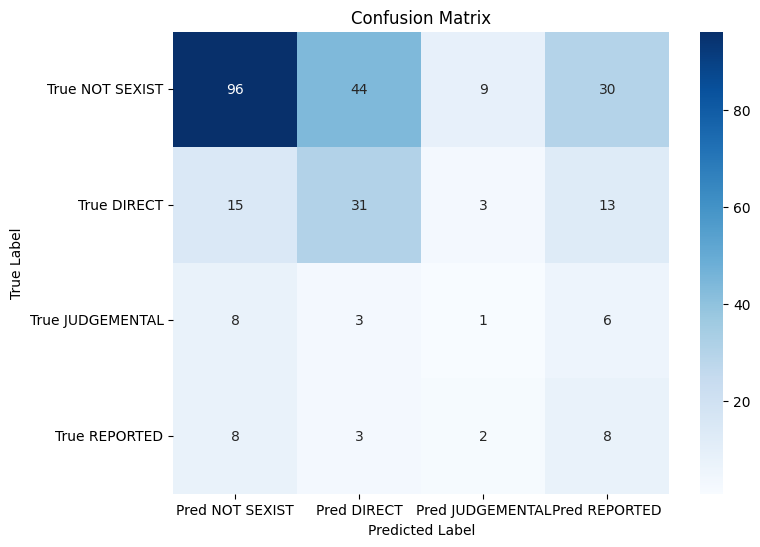


Training stacked model with seed 2026...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 33%|██    | 10/30 [02:03<04:08, 12.44s/epoch, accuracy=0.747, f1_score=0.747, loss=0.923, val_accuracy=0.44, val_f1_score=0.315, val_loss=1.71, learning_rate=0.001]


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 43%|██▏  | 13/30 [02:35<03:14, 11.41s/epoch, accuracy=0.829, f1_score=0.827, loss=0.74, val_accuracy=0.447, val_f1_score=0.305, val_loss=2.09, learning_rate=0.0005]

Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


 43%|██▏  | 13/30 [02:35<03:23, 12.00s/epoch, accuracy=0.829, f1_score=0.827, loss=0.74, val_accuracy=0.447, val_f1_score=0.305, val_loss=2.09, learning_rate=0.0005]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.78      0.52      0.62       179
      DIRECT       0.33      0.56      0.42        62
 JUDGEMENTAL       0.15      0.28      0.19        18
    REPORTED       0.09      0.10      0.09        21

    accuracy                           0.48       280
   macro avg       0.34      0.36      0.33       280
weighted avg       0.59      0.48      0.51       280

---------------------------------

Plotting Confusion Matrix...


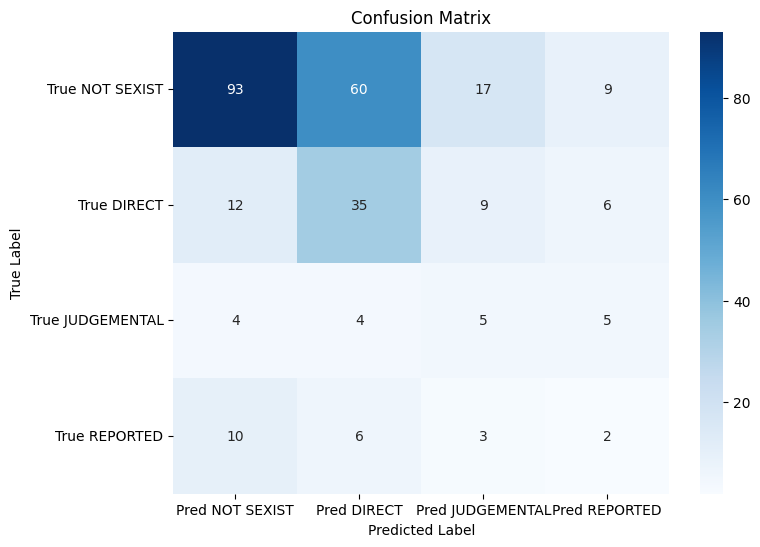


Training baseline model with seed 8...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 23%|██▎       | 7/30 [00:42<02:11,  5.72s/epoch, accuracy=0.79, f1_score=0.786, loss=0.676, val_accuracy=0.4, val_f1_score=0.29, val_loss=1.55, learning_rate=0.001]


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 33%|█▋   | 10/30 [00:59<01:52,  5.61s/epoch, accuracy=0.842, f1_score=0.839, loss=0.536, val_accuracy=0.52, val_f1_score=0.364, val_loss=1.56, learning_rate=0.0005]

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


 33%|█▋   | 10/30 [00:59<01:58,  5.91s/epoch, accuracy=0.842, f1_score=0.839, loss=0.536, val_accuracy=0.52, val_f1_score=0.364, val_loss=1.56, learning_rate=0.0005]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.87      0.35      0.50       179
      DIRECT       0.36      0.74      0.48        62
 JUDGEMENTAL       0.18      0.39      0.25        18
    REPORTED       0.12      0.24      0.16        21

    accuracy                           0.43       280
   macro avg       0.38      0.43      0.35       280
weighted avg       0.66      0.43      0.45       280

---------------------------------

Plotting Confusion Matrix...


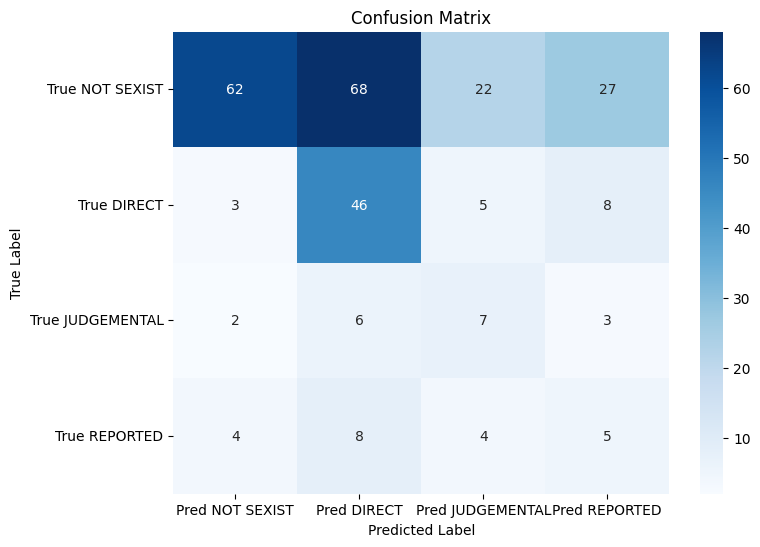


Training stacked model with seed 8...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 33%|██    | 10/30 [01:54<03:53, 11.68s/epoch, accuracy=0.804, f1_score=0.807, loss=0.798, val_accuracy=0.42, val_f1_score=0.289, val_loss=1.81, learning_rate=0.001]


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 47%|██▊   | 14/30 [02:38<02:59, 11.21s/epoch, accuracy=0.875, f1_score=0.874, loss=0.648, val_accuracy=0.5, val_f1_score=0.322, val_loss=1.58, learning_rate=0.0005]


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


...


Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


 70%|████▏ | 21/30 [03:58<01:40, 11.12s/epoch, accuracy=0.935, f1_score=0.935, loss=0.471, val_accuracy=0.48, val_f1_score=0.317, val_loss=2, learning_rate=0.000125]

Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.


 70%|████▏ | 21/30 [03:58<01:42, 11.34s/epoch, accuracy=0.935, f1_score=0.935, loss=0.471, val_accuracy=0.48, val_f1_score=0.317, val_loss=2, learning_rate=0.000125]



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.81      0.58      0.68       179
      DIRECT       0.35      0.69      0.47        62
 JUDGEMENTAL       0.13      0.11      0.12        18
    REPORTED       0.07      0.05      0.06        21

    accuracy                           0.54       280
   macro avg       0.34      0.36      0.33       280
weighted avg       0.61      0.54      0.55       280

---------------------------------

Plotting Confusion Matrix...


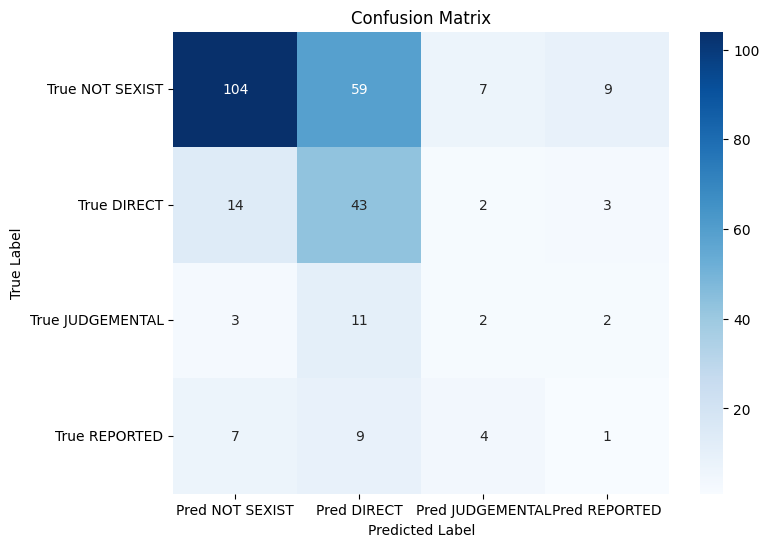


Training baseline model with seed 314...


0epoch [00:00, ?epoch/s]/usr/local/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning:

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.

 30%|██▍     | 9/30 [00:50<01:57,  5.57s/epoch, accuracy=0.843, f1_score=0.841, loss=0.546, val_accuracy=0.5, val_f1_score=0.271, val_loss=1.46, learning_rate=0.001]


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 40%|██▍   | 12/30 [01:10<01:51,  6.21s/epoch, accuracy=0.881, f1_score=0.88, loss=0.445, val_accuracy=0.58, val_f1_score=0.293, val_loss=1.54, learning_rate=0.0005]


Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


 43%|██▏  | 13/30 [01:15<01:42,  6.01s/epoch, accuracy=0.892, f1_score=0.891, loss=0.42, val_accuracy=0.567, val_f1_score=0.304, val_loss=1.57, learning_rate=0.0005]

In [ ]:
# Hyperparameters
EPOCHS = 30
SEEDS = [123, 420, 2026, 8, 314, 666, 42, 13, 271, 667]
BATCH_SIZE = 512

classes = [0, 1, 2, 3]
history_best = []
evaluations = []

for seed, model_data in list(product(SEEDS, [(False, study_base.best_params), (True, study_stacked.best_params)])):
    stacked, study = model_data
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    set_deterministic(seed)
    model = build_model(units=study['units'],
            dense=study['dense'],
            trainable_embeddings=study['trainable_emb'],
            stacked=stacked,
            lr=study['lr'],
            dropout=study['dropout'],
            l2=study['l2'])

    history = model.fit(
        x=X_train_vec,
        y=y_train,
        validation_data=(X_val_vec, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(True),
        verbose=0,
        shuffle=True
    )
    evaluations.append(evaluate_model(model, X_test, y_test))
    if len(history_best) <= int(stacked):
        history_best.append((history, f1, seed))
        model.save(f"best_{"stacked" if stacked else "base"}.keras")
    if f1 > history_best[stacked][1]:
        history_best[stacked] = (history, f1, seed)
        model.save(f"best_{"stacked" if stacked else "base"}.keras")

evals_base = evaluations[:len(SEEDS)]
evals_stacked = evaluations[len(SEEDS):]
print("Base model avg. results:")
print(f"- Precision: {np.average([elem[1] for elem in evals_base])}±{np.std([elem[1] for elem in evals_base])}")
print(f"- Recall: {np.average([elem[2] for elem in evals_base])}±{np.std([elem[2] for elem in evals_base])}")
print(f"- F1: {np.average([elem[0] for elem in evals_base])}±{np.std([elem[0] for elem in evals_base])}")
print("\nStacked model avg. results:")
print(f"- Precision: {np.average([elem[1] for elem in evals_stacked])}±{np.std([elem[1] for elem in evals_stacked])}")
print(f"- Recall: {np.average([elem[2] for elem in evals_stacked])}±{np.std([elem[2] for elem in evals_stacked])}")
print(f"- F1: {np.average([elem[0] for elem in evals_stacked])}±{np.std([elem[0] for elem in evals_stacked])}")



In [ ]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0][0].history['loss'], label='Base Model Training Loss')
plt.plot(history_best[0][0].history['val_loss'], label='Base Model Validation Loss')
plt.title(f'Base Model Training and Validation Loss (SEED={history_best[0][2]})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0][0].history['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0][0].history['val_accuracy'], label='Base Model Validation Accuracy')
plt.title(f'Base Model Training and Validation Accuracy (SEED={history_best[0][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[0][0].history['f1_score'], label='Base Model Training F1')
plt.plot(history_best[0][0].history['val_f1_score'], label='Base Model Validation F1')
plt.title(f'Stacked Model Training and Validation F1 (SEED={history_best[0][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1][0].history['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1][0].history['val_loss'], label='Stacked Model Validation Loss')
plt.title(f'Stacked Model Training and Validation Loss (SEED={history_best[1][2]})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1][0].history['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1][0].history['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title(f'Stacked Model Training and Validation Accuracy (SEED={history_best[1][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1][0].history['f1_score'], label='Stacked Model Training F1')
plt.plot(history_best[1][0].history['val_f1_score'], label='Stacked Model Validation F1')
plt.title(f'Stacked Model Training and Validation F1 (SEED={history_best[1][2]})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Task 6: Transformers

### Load & Preprocess data

In [ ]:
train_ROBERTA = random_upsampler(train_ROBERTA)

AUGMENTATION DONE!


In [ ]:
train_ds = Dataset.from_pandas(train_ROBERTA)
valid_ds = Dataset.from_pandas(val_ROBERTA)
test_ds = Dataset.from_pandas(test_ROBERTA)

### Load tokenizer & tokenize the data

In [ ]:
model_card = "cardiffnlp/twitter-roberta-base-hate"
tokenizer = AutoTokenizer.from_pretrained(model_card)

In [ ]:
# Preprocess the Dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

# Map tokenization to the Dataset objects
train_dataset = train_ds.map(tokenize_function, batched=True)
val_dataset = valid_ds.map(tokenize_function, batched=True)
test_dataset = test_ds.map(tokenize_function, batched=True)

# Data format (will be used in Trainer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/8056 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

### Helper functions to report results

In [ ]:
def show_learning_curves(trainer_history, seed):
    epochs_loss = []
    train_loss = []
    epochs_eval = []
    val_loss = []
    val_f1 = []

    for entry in trainer_history:
        if 'loss' in entry:
            train_loss.append(entry['loss'])
            epochs_loss.append(entry['epoch'])
        if 'eval_loss' in entry:
            val_loss.append(entry['eval_loss'])
            val_f1.append(entry['eval_f1'])
            epochs_eval.append(entry['epoch'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(epochs_loss, train_loss, label='Training Loss', marker='o')
    ax1.plot(epochs_eval, val_loss, label='Validation Loss', marker='x')
    ax1.set_title(f'Loss Curves - Seed {seed}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # F1 Plot
    ax2.plot(epochs_eval, val_f1, label='Validation F1', color='green', marker='s')
    ax2.set_title(f'F1 Score Curve - Seed {seed}')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def report_detailed_metrics(trainer, dataset, seed):
    # Get predictions
    output = trainer.predict(dataset)
    y_true = output.label_ids
    y_pred = np.argmax(output.predictions, axis=-1)

    target_names = ["Non SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]

    # Classification Report
    print(f"\n--- Classification Report (Seed {seed}) ---")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix (Seed {seed})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

### Setup evaluation metrics

In [ ]:
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc_res = acc_metric.compute(predictions=predictions, references=labels)
    # Compute all macro metrics
    f1_res = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    precision_res = precision_metric.compute(predictions=predictions, references=labels, average='macro', zero_division=0.0)
    recall_res = recall_metric.compute(predictions=predictions, references=labels, average='macro', zero_division=0.0)

    # Return with explicit keys to match TrainingArguments
    return {
        "accuracy": acc_res['accuracy'],
        "f1": f1_res['f1'],
        "precision": precision_res['precision'],
        "recall": recall_res['recall']
    }

### Fine-tuning


RUNNING WITH SEED: 123


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.057500,0.889205,0.640000,0.448197,0.447119,0.493504
2,0.925200,0.820886,0.680000,0.505315,0.483295,0.558722
3,0.874700,0.867674,0.640000,0.463524,0.476758,0.497671
4,0.839000,0.875390,0.660000,0.498514,0.496966,0.538768


model for seed 123 saved to ./model_seed__123


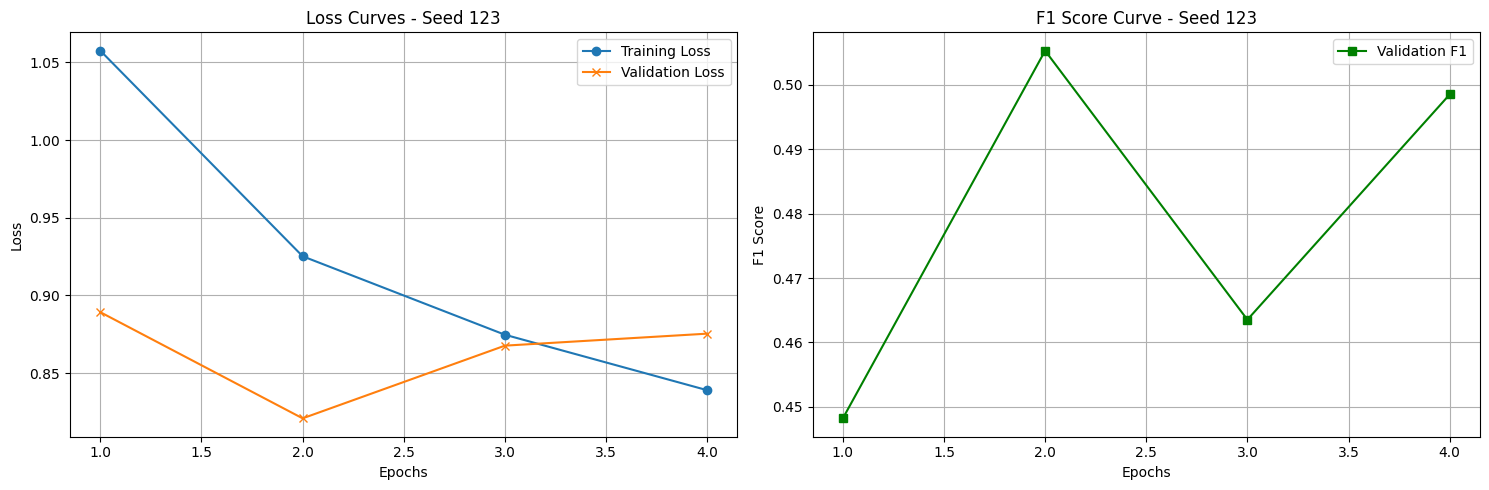

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.5053150692821249

Evaluating Seed 123 on Test Set...

--- Classification Report (Seed 123) ---
              precision    recall  f1-score   support

  Non SEXIST       0.92      0.74      0.82       179
      DIRECT       0.61      0.69      0.65        62
 JUDGEMENTAL       0.16      0.22      0.19        18
    REPORTED       0.35      0.67      0.46        21

    accuracy                           0.69       280
   macro avg       0.51      0.58      0.53       280
weighted avg       0.76      0.69      0.72       280



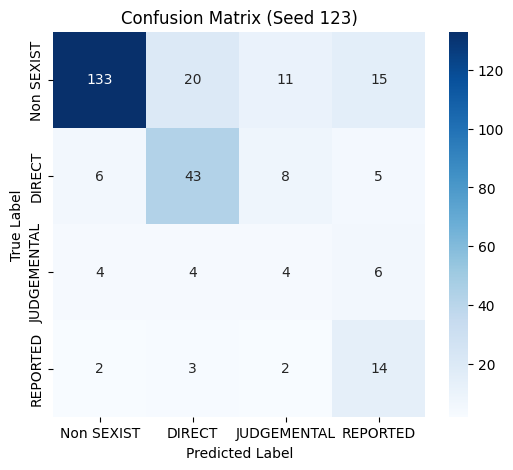

Test F1 (Macro): 0.5293914277266673

RUNNING WITH SEED: 12


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.061400,0.902545,0.640000,0.463821,0.455966,0.518970
2,0.928300,0.912504,0.653333,0.491772,0.478023,0.554840
3,0.868000,0.908542,0.653333,0.468562,0.469444,0.520885
4,0.848300,0.866141,0.666667,0.498048,0.477715,0.553960
5,0.819100,0.856978,0.700000,0.529661,0.513787,0.579995
6,0.804300,0.909263,0.660000,0.493795,0.483338,0.548732
7,0.798700,0.868426,0.686667,0.512077,0.495413,0.566744


model for seed 12 saved to ./model_seed__12


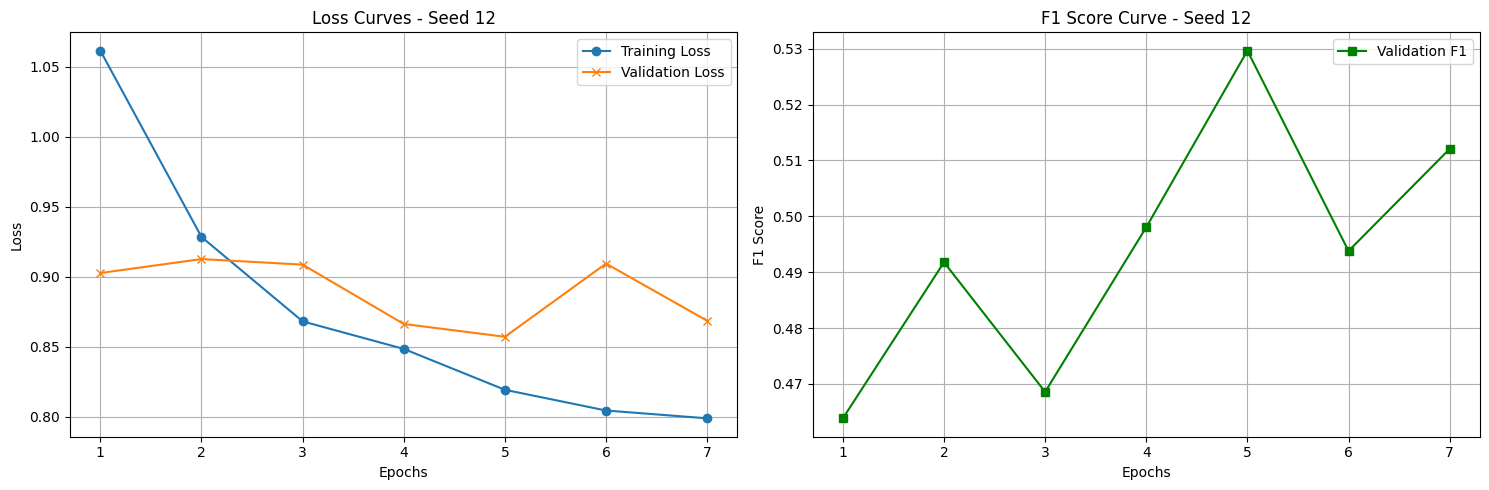

Retrieving best validation metrics for Seed 12...


Best Validation F1 (Macro): 0.5296612026647965

Evaluating Seed 12 on Test Set...

--- Classification Report (Seed 12) ---
              precision    recall  f1-score   support

  Non SEXIST       0.93      0.73      0.82       179
      DIRECT       0.67      0.65      0.66        62
 JUDGEMENTAL       0.19      0.33      0.24        18
    REPORTED       0.29      0.67      0.41        21

    accuracy                           0.68       280
   macro avg       0.52      0.59      0.53       280
weighted avg       0.78      0.68      0.71       280



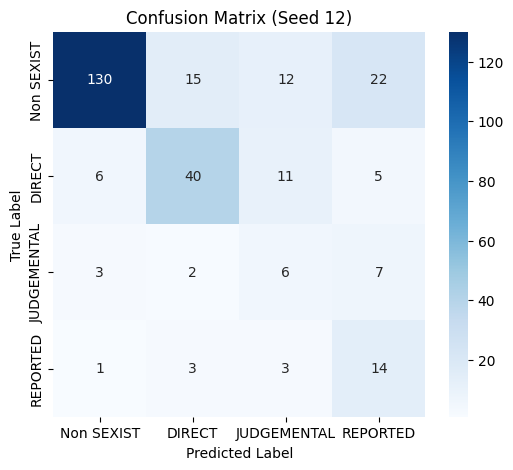

Test F1 (Macro): 0.5291454570777205

RUNNING WITH SEED: 2028


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.054100,0.867159,0.686667,0.501587,0.480696,0.552614
2,0.921800,0.934797,0.646667,0.484489,0.486028,0.535481
3,0.874700,0.857343,0.680000,0.513991,0.495059,0.572852
4,0.847500,0.886104,0.673333,0.509773,0.490246,0.570471
5,0.812200,0.866955,0.686667,0.525471,0.511161,0.575233
6,0.810200,0.899307,0.673333,0.504414,0.491972,0.561982
7,0.803400,0.875864,0.686667,0.523031,0.502888,0.583722


model for seed 2028 saved to ./model_seed__2028


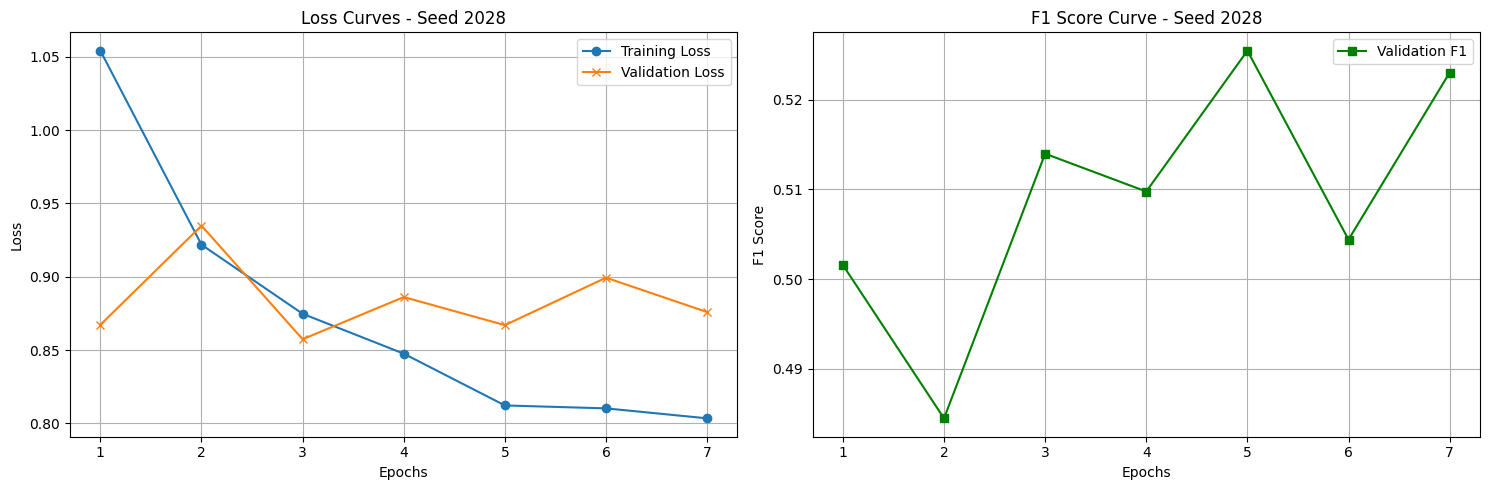

Retrieving best validation metrics for Seed 2028...


Best Validation F1 (Macro): 0.5254712996309635

Evaluating Seed 2028 on Test Set...

--- Classification Report (Seed 2028) ---
              precision    recall  f1-score   support

  Non SEXIST       0.92      0.71      0.80       179
      DIRECT       0.59      0.66      0.63        62
 JUDGEMENTAL       0.19      0.39      0.26        18
    REPORTED       0.27      0.48      0.34        21

    accuracy                           0.66       280
   macro avg       0.49      0.56      0.51       280
weighted avg       0.75      0.66      0.69       280



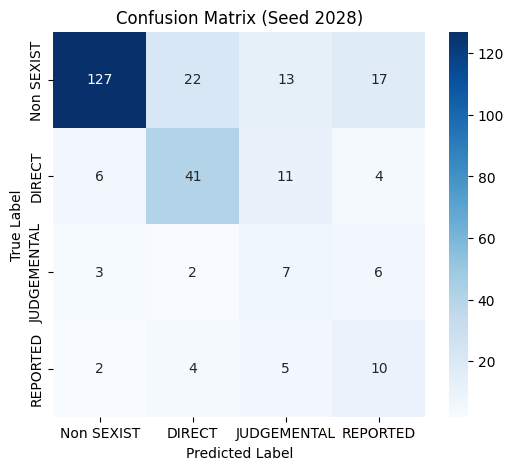

Test F1 (Macro): 0.5078257183981087

########################################
INDIVIDUAL SEED RESULTS
########################################
 Seed  Valid Accuracy  Valid Precision  Valid Recall  Valid F1  Test Accuracy  Test Precision  Test Recall  Test F1
  123        0.680000         0.483295      0.558722  0.505315       0.692857        0.510382     0.581364 0.529391
   12        0.700000         0.513787      0.579995  0.529661       0.678571        0.518601     0.592855 0.529145
 2028        0.686667         0.511161      0.575233  0.525471       0.660714        0.494802     0.558967 0.507826

########################################
ROBUST ESTIMATION (SUMMARY)
########################################
                     mean       std
Valid Accuracy   0.688889  0.010184
Valid Precision  0.502748  0.016898
Valid Recall     0.571316  0.011164
Valid F1         0.520149  0.013016
Test Accuracy    0.677381  0.016104
Test Precision   0.507928  0.012088
Test Recall      0.577728  0.0

In [ ]:
seeds = [123, 12, 2028]
results_list = []

# Load the Model
# Mappings as specified in Task 1 instructions
label2id = {
    "-": 0,
    "DIRECT": 1,
    "JUDGEMENTAL": 2,
    "REPORTED": 3
}

id2label = {v: k for k, v in label2id.items()}
model_card = "cardiffnlp/twitter-roberta-base-hate"

# Update the Training Loop with Freezing and Label Smoothing
for seed in seeds:
    print(f"\n" + "="*60)
    print(f"RUNNING WITH SEED: {seed}")
    print("="*60)

    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_card,
        num_labels=4,
        label2id=label2id,
        id2label=id2label,
        ignore_mismatched_sizes=True # Required because original model has 2 labels
    ).to(device)                     # And, in this way, it reinitiate a new classifier head with random weights to be learned by fine-tuning

    # FREEZE RoBERTa ENCODER
    # We freeze all layers of the base model except for the classification head
    for name, param in model.roberta.named_parameters():
        param.requires_grad = False

    training_args = TrainingArguments(
        learning_rate=5e-5,
        lr_scheduler_type="cosine",           # Cosine decay for smooth convergence
        weight_decay=0.01,                    # L2 Regularization
        num_train_epochs=10,                  # Managed by Early Stopping
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",           # Optimize for Macro F1
        seed = seed,
        report_to="none"                      # Give up dear wandb :)
    )

    class MyTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            # Explicitly pull the components from the input dictionary
            labels = inputs.get("labels")
            mask = inputs.get("attention_mask")
            input_ids = inputs.get("input_ids")

            outputs = model(
                input_ids=input_ids,
                attention_mask=mask,
                labels=labels
            )

            logits = outputs.get("logits")
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

            return (loss, outputs) if return_outputs else loss

    trainer = MyTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # SAVE THE BEST MODEL
    # This saves the model, tokenizer, and config to the directory
    save_path = f"./model_seed__{seed}"
    trainer.save_model(save_path)
    print(f"model for seed {seed} saved to {save_path}")

    # Learning Curves, Metrics, and Confusion Matrix
    show_learning_curves(trainer.state.log_history, seed)

    # Retrieve Best Validation Metrics (from the best checkpoint loaded at the end)
    print(f"Retrieving best validation metrics for Seed {seed}...")

    val_metrics = trainer.evaluate(val_dataset)
    print(f"Best Validation F1 (Macro): {val_metrics["eval_f1"]}")

    # Detailed Performance on Test Set
    print(f"\nEvaluating Seed {seed} on Test Set...")
    report_detailed_metrics(trainer, test_dataset, seed)

    # Remove the callback so it doesn't look for eval_f1 during test evaluation
    trainer.pop_callback(EarlyStoppingCallback)

    # Evaluate on the Test Set for this specific seed
    test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")
    print(f"Test F1 (Macro): {test_metrics["test_f1"]}")

    # Store both sets of results
    results_list.append({
        "Seed": seed,
        "Valid Accuracy": val_metrics["eval_accuracy"],
        "Valid Precision": val_metrics["eval_precision"],
        "Valid Recall": val_metrics["eval_recall"],
        "Valid F1": val_metrics["eval_f1"],
        "Test Accuracy": test_metrics["test_accuracy"],
        "Test Precision": test_metrics["test_precision"],
        "Test Recall": test_metrics["test_recall"],
        "Test F1": test_metrics["test_f1"]
    })

# Reporting Results
# 1. Report for each seed separately first
print("\n" + "#"*40)
print("INDIVIDUAL SEED RESULTS")
print("#"*40)
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

# 2. Report average and standard deviation
print("\n" + "#"*40)
print("ROBUST ESTIMATION (SUMMARY)")
print("#"*40)

summary_stats = results_df.drop(columns='Seed').agg(['mean', 'std']).T
print(summary_stats)

## Error Analysis